In [12]:
# Use LOG RETURNS instead of price — removes the level problem entirely.
# A 3% crash looks the same at 30K or 80K. Autoencoder learns normal return patterns.
# Unusual return sequences (COVID crash, flash crashes) get flagged correctly.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense,
                                     RepeatVector, TimeDistributed)
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
SEQ_LEN = 60

# ── Use log returns (stationary — no price level bias) ────────────────────────
returns       = df['LogReturn'].dropna().values.reshape(-1, 1)
return_dates  = df.index[df['LogReturn'].notna()]

ae_scaler     = MinMaxScaler(feature_range=(-1, 1))
returns_scaled = ae_scaler.fit_transform(returns)

# ── Build sequences ───────────────────────────────────────────────────────────
X_full_ae, dates_ae = [], []
for i in range(len(returns_scaled) - SEQ_LEN):
    X_full_ae.append(returns_scaled[i:i+SEQ_LEN])
    dates_ae.append(return_dates[i + SEQ_LEN])
X_full_ae = np.array(X_full_ae)
dates_ae  = pd.DatetimeIndex(dates_ae)

# ── Train on pre-2020 only ────────────────────────────────────────────────────
pre2020_mask = dates_ae < '2020-01-01'
X_train_ae   = X_full_ae[pre2020_mask]

print(f"Full sequences  : {X_full_ae.shape}")
print(f"Train (pre-2020): {X_train_ae.shape}")
print(f"  {dates_ae[pre2020_mask][0].date()} → {dates_ae[pre2020_mask][-1].date()}")
print(f"Test  (2020+)   : {X_full_ae[~pre2020_mask].shape}")
print(f"\nLog return stats:")
print(f"  Mean : {df['LogReturn'].mean()*100:.4f}%")
print(f"  Std  : {df['LogReturn'].std()*100:.4f}%")
print(f"  Min  : {df['LogReturn'].min()*100:.2f}%  on {df['LogReturn'].idxmin().date()}")
print(f"  Max  : {df['LogReturn'].max()*100:.2f}%  on {df['LogReturn'].idxmax().date()}")

Full sequences  : (2353, 60, 1)
Train (pre-2020): (871, 60, 1)
  2016-06-14 → 2019-12-31
Test  (2020+)   : (1482, 60, 1)

Log return stats:
  Mean : 0.0511%
  Std  : 1.0305%
  Min  : -14.10%  on 2020-03-23
  Max  : 8.59%  on 2020-04-07


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 60, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 60, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 60, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,737 (151.32 KB)

 Trainable params: 38,737 (151.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0289 - val_loss: 0.0102
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0066 - val_loss: 0.0098
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0057 - val_loss: 0.0095
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0053 - val_loss: 0.0092
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0049 - val_loss: 0.0090
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0047 - val_loss: 0.0088
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0045 - val_loss: 0.0085
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0043 - val_loss: 0.0084
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - loss: 0.0042 - val_loss: 0.0083
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0042 - val_loss: 0.0084
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0042 - val_loss: 0.0083
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/st

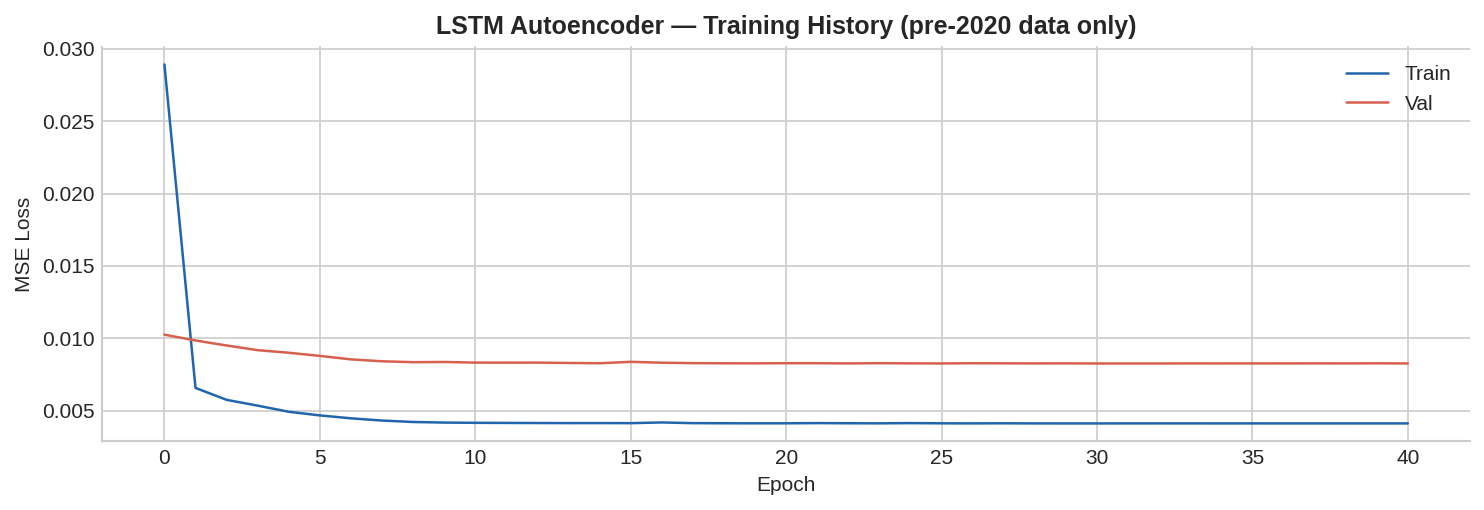

In [13]:
# Encoder compresses 60-day window → 16-dim bottleneck → decoder reconstructs.
# Trained only on pre-2020 calm market data.
# High reconstruction error = sequence looks nothing like pre-2020 normality.

tf.random.set_seed(42)

inp        = Input(shape=(SEQ_LEN, 1))
enc        = LSTM(64, activation='relu', return_sequences=False)(inp)
bottleneck = Dense(16, activation='relu')(enc)
dec        = RepeatVector(SEQ_LEN)(bottleneck)
dec        = LSTM(64, activation='relu', return_sequences=True)(dec)
out        = TimeDistributed(Dense(1))(dec)

autoencoder = Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

history_ae = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True, verbose=1)],
    verbose=1
)

# Training curve
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(history_ae.history['loss'],     color=BLUE, lw=1.2, label='Train')
ax.plot(history_ae.history['val_loss'], color=RED,  lw=1.2, label='Val')
ax.set_title('LSTM Autoencoder — Training History (pre-2020 data only)',
             fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('ae_training.png', dpi=300, bbox_inches='tight')
plt.show()

Train error μ   : 0.004532
Train error σ   : 0.002210
Threshold (μ+3σ): 0.011163

LSTM AE anomalies: 257 (10.9% of all days)
  2020: 102 anomalous days
  2021: 60 anomalous days
  2022: 86 anomalous days
  2023: 0 anomalous days
  2024: 9 anomalous days
Isolation Forest: 121 anomalies (5.0%)

AE only            : 185
IF only            : 49
Consensus (both)   : 72


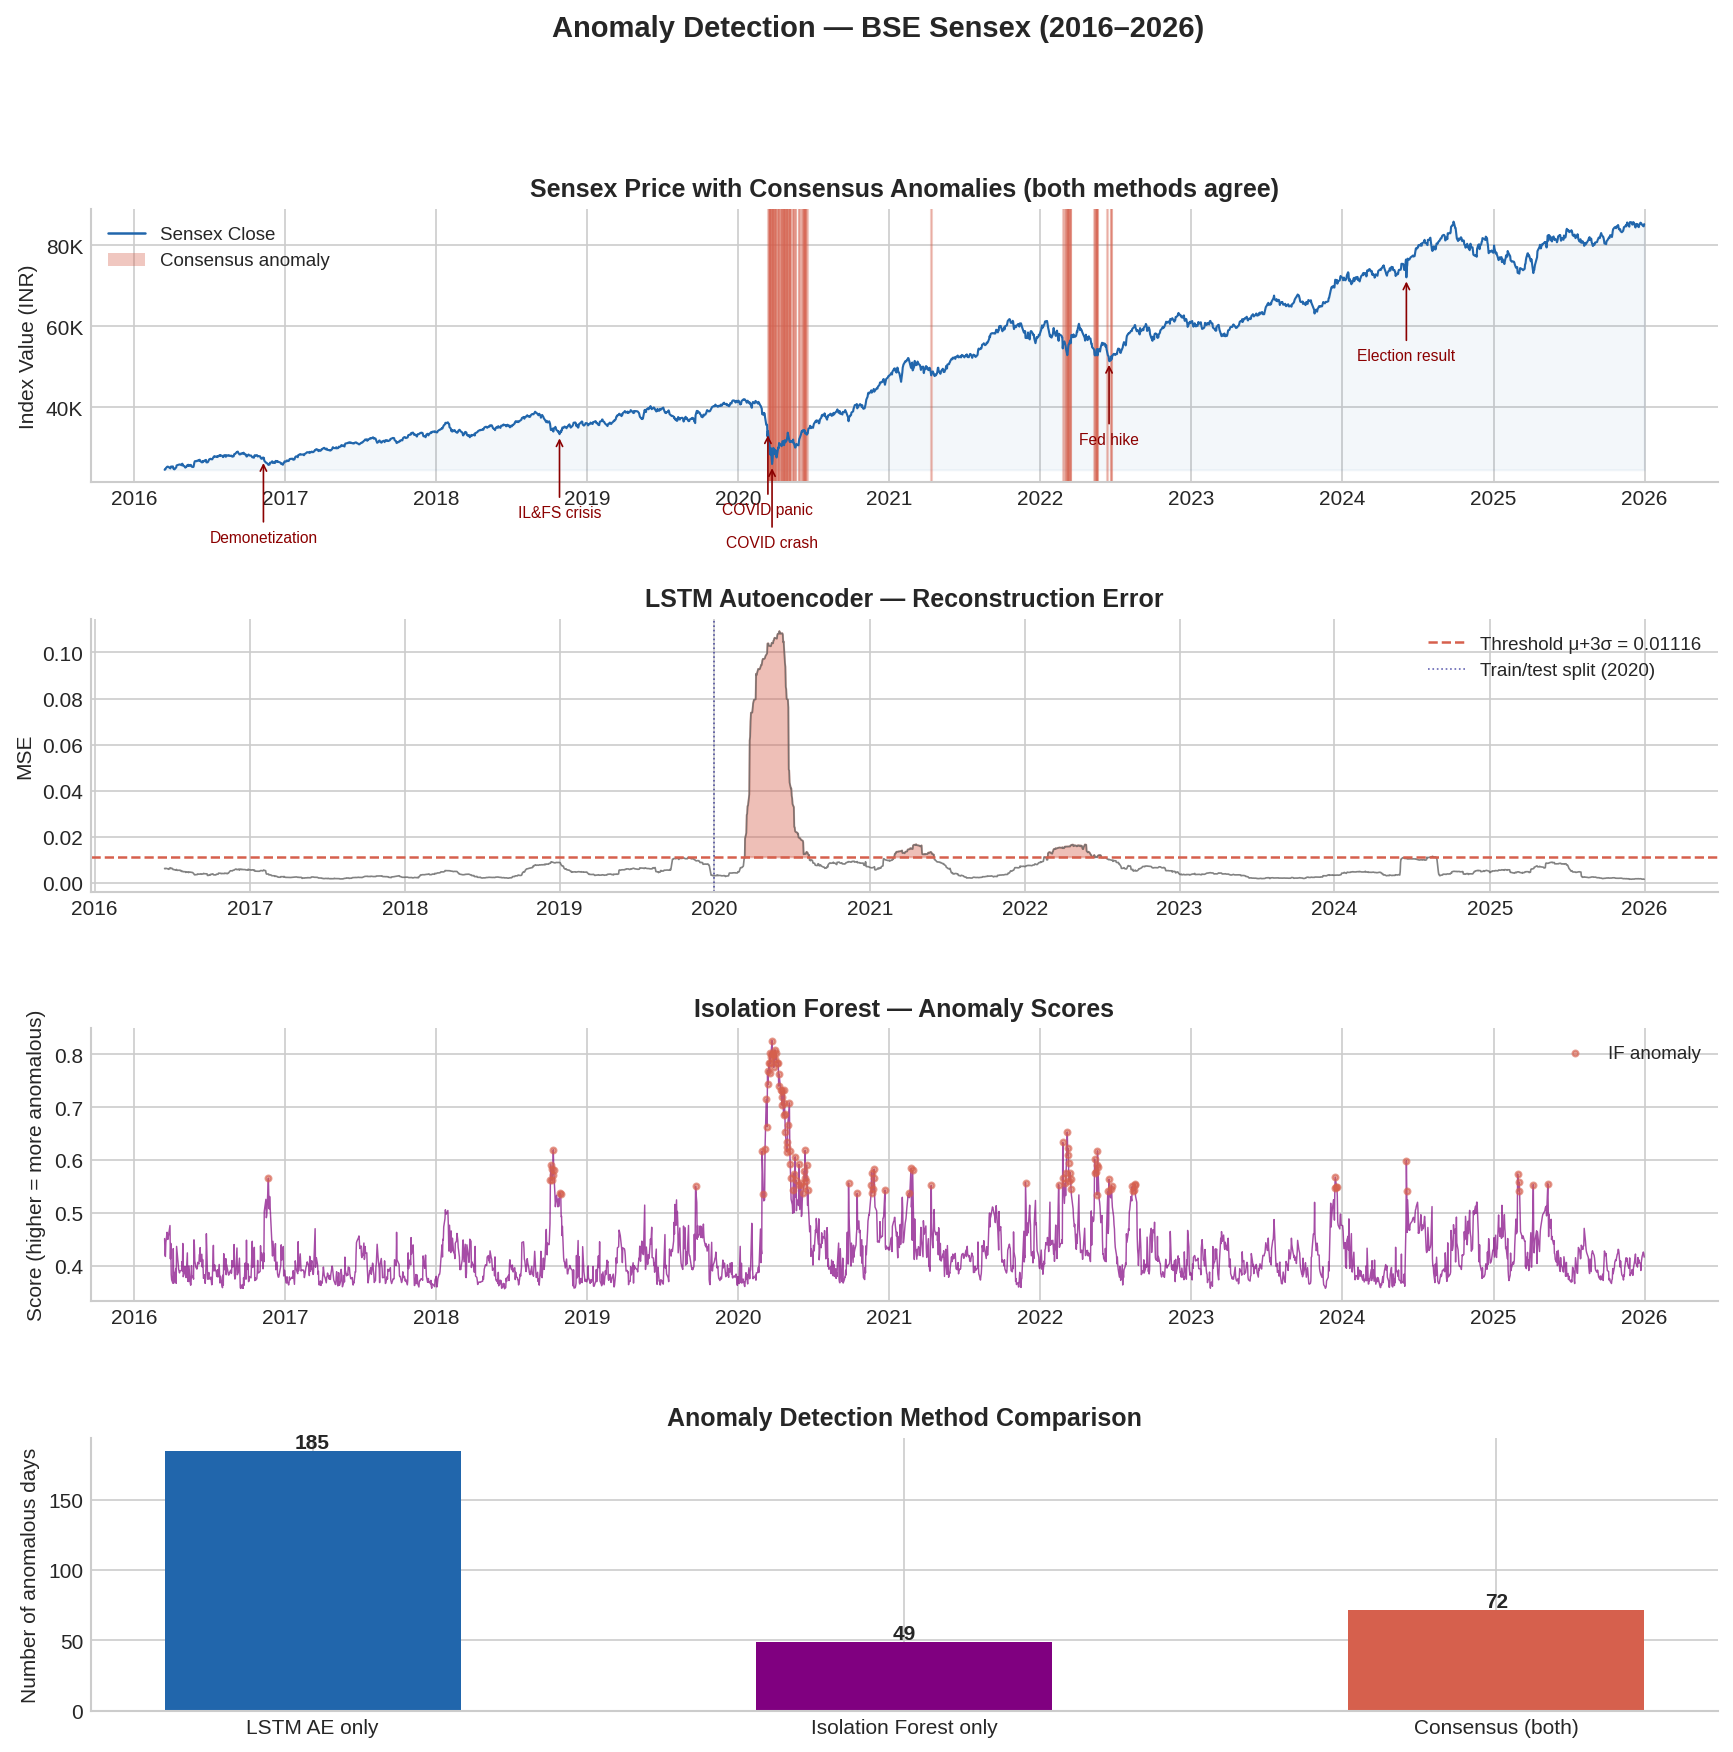


=== Top 20 anomalous dates (LSTM Autoencoder) ===
            Reconstruction_Error         Close  DailyReturn_%  IF_Anomaly
2020-04-07              0.079679  30067.210938       8.974906        True
2020-04-08              0.090749  29893.960938      -0.576209        True
2020-04-09              0.090099  31159.619141       4.233826        True
2020-04-13              0.092846  30690.019531      -1.507078        True
2020-04-15              0.092768  30379.810547      -1.010781        True
2020-04-16              0.092690  30602.609375       0.733378        True
2020-04-17              0.092899  31588.720703       3.222311        True
2020-04-20              0.094563  31648.000000       0.187660        True
2020-04-21              0.094504  30636.710938      -3.195428        True
2020-04-22              0.095494  31379.550781       2.424672        True
2020-04-23              0.096591  31863.080078       1.540906        True
2020-04-24              0.097182  31327.220703      -1.681756

In [15]:
# Anomaly score = reconstruction error (MSE per 60-day window).
# Threshold set at μ + 3σ of PRE-2020 training errors only — strict cutoff.
# Isolation Forest runs on technical features as a second independent method.
# Consensus anomalies (both methods agree) are the most reliable signals.

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ══════════════════════════════════════════════════════════════════
# PART 1 — LSTM AUTOENCODER SCORING
# ══════════════════════════════════════════════════════════════════
X_reconstructed       = autoencoder.predict(X_full_ae, verbose=0)
reconstruction_errors = np.mean(
    np.power(X_full_ae - X_reconstructed, 2), axis=(1, 2)
)

# Threshold from PRE-2020 training errors only
train_errors = reconstruction_errors[pre2020_mask]
mu, sigma    = np.mean(train_errors), np.std(train_errors)
threshold    = mu + 3 * sigma   # strict — ~0.1% false positive rate on normal data

print(f"Train error μ   : {mu:.6f}")
print(f"Train error σ   : {sigma:.6f}")
print(f"Threshold (μ+3σ): {threshold:.6f}")

ae_anomaly_mask  = reconstruction_errors > threshold
ae_anomaly_dates = dates_ae[ae_anomaly_mask]

print(f"\nLSTM AE anomalies: {ae_anomaly_mask.sum()} "
      f"({ae_anomaly_mask.mean()*100:.1f}% of all days)")

# Year breakdown
for year in [2020, 2021, 2022, 2023, 2024]:
    n = sum(1 for d in ae_anomaly_dates if d.year == year)
    print(f"  {year}: {n} anomalous days")

# ══════════════════════════════════════════════════════════════════
# PART 2 — ISOLATION FOREST
# ══════════════════════════════════════════════════════════════════
# ── Isolation Forest on return-based features (not price) ─────────────────────
IF_FEATURES = ['LogReturn', 'RealVol_20', 'RSI_14', 'MACD', 'BB_width']
df_if       = df[IF_FEATURES].dropna()

if_scaler   = StandardScaler()
X_if        = if_scaler.fit_transform(df_if)

iso_forest  = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=42
)
if_labels        = iso_forest.fit_predict(X_if)
if_scores        = -iso_forest.score_samples(X_if)
if_anomaly_mask  = if_labels == -1
if_anomaly_dates = df_if.index[if_anomaly_mask]

print(f"Isolation Forest: {if_anomaly_mask.sum()} anomalies "
      f"({if_anomaly_mask.mean()*100:.1f}%)")
# ══════════════════════════════════════════════════════════════════
# PART 3 — CONSENSUS (both agree)
# ══════════════════════════════════════════════════════════════════
# Align both on common dates
common_dates   = dates_ae.intersection(df_if.index)
ae_on_common   = pd.Series(ae_anomaly_mask,
                           index=dates_ae).reindex(common_dates).fillna(False)
if_on_common   = pd.Series(if_anomaly_mask,
                           index=df_if.index).reindex(common_dates).fillna(False)

consensus_mask  = ae_on_common & if_on_common
consensus_dates = common_dates[consensus_mask]

print(f"\nAE only            : {(ae_on_common & ~if_on_common).sum()}")
print(f"IF only            : {(~ae_on_common & if_on_common).sum()}")
print(f"Consensus (both)   : {consensus_mask.sum()}")

# ══════════════════════════════════════════════════════════════════
# PART 4 — PUBLICATION FIGURE
# ══════════════════════════════════════════════════════════════════
known_events = {
    '2020-03-23': 'COVID crash',
    '2020-03-13': 'COVID panic',
    '2018-10-26': 'IL&FS crisis',
    '2022-06-16': 'Fed hike',
    '2024-06-04': 'Election result',
    '2016-11-09': 'Demonetization',
}

fig = plt.figure(figsize=(14, 13))
gs  = gridspec.GridSpec(4, 1, hspace=0.50)
fig.suptitle('Anomaly Detection — BSE Sensex (2016–2026)',
             fontsize=14, fontweight='bold')

# ── Panel 1: Price + consensus anomalies ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df['Close'], color=BLUE, lw=1, zorder=3)
ax1.fill_between(df.index, df['Close'], df['Close'].min(),
                 alpha=0.05, color=BLUE)

for date in consensus_dates:
    ax1.axvspan(date - pd.Timedelta(days=1),
                date + pd.Timedelta(days=1),
                alpha=0.3, color=RED, zorder=2)

for date_str, label in known_events.items():
    ts = pd.Timestamp(date_str)
    near = df.index[df.index.get_indexer([ts], method='nearest')[0]]
    y    = df.loc[near, 'Close']
    ax1.annotate(label, xy=(near, y),
                 xytext=(0, -40), textcoords='offset points',
                 fontsize=7.5, color='darkred', ha='center',
                 arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

ax1.set_title('Sensex Price with Consensus Anomalies (both methods agree)',
              fontweight='bold')
ax1.set_ylabel('Index Value (INR)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.legend(handles=[
    plt.Line2D([0],[0], color=BLUE, lw=1.2, label='Sensex Close'),
    Patch(facecolor=RED, alpha=0.35, label='Consensus anomaly')
], fontsize=9)

# ── Panel 2: Reconstruction error ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(dates_ae, reconstruction_errors, color=GRAY, lw=0.8, alpha=0.8)
ax2.axhline(threshold, color=RED, lw=1.2, ls='--',
            label=f'Threshold μ+3σ = {threshold:.5f}')
ax2.fill_between(dates_ae, reconstruction_errors, threshold,
                 where=(reconstruction_errors > threshold),
                 alpha=0.4, color=RED)
ax2.axvline(pd.Timestamp('2020-01-01'), color='navy',
            lw=0.8, ls=':', alpha=0.6, label='Train/test split (2020)')
ax2.set_title('LSTM Autoencoder — Reconstruction Error', fontweight='bold')
ax2.set_ylabel('MSE')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.legend(fontsize=9)

# ── Panel 3: Isolation Forest anomaly scores ──────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(df_if.index, if_scores, color='purple', lw=0.7, alpha=0.7)
ax3.scatter(if_anomaly_dates,
            if_scores[if_anomaly_mask],
            color=RED, s=8, zorder=4, alpha=0.6, label='IF anomaly')
ax3.set_title('Isolation Forest — Anomaly Scores', fontweight='bold')
ax3.set_ylabel('Score (higher = more anomalous)')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.legend(fontsize=9)

# ── Panel 4: Venn-style bar comparison ───────────────────────────────────────
ax4 = fig.add_subplot(gs[3])
categories = ['LSTM AE only', 'Isolation Forest only', 'Consensus (both)']
counts     = [
    int((ae_on_common & ~if_on_common).sum()),
    int((~ae_on_common & if_on_common).sum()),
    int(consensus_mask.sum())
]
colors_bar = [BLUE, 'purple', RED]
bars = ax4.bar(categories, counts, color=colors_bar,
               edgecolor='none', width=0.5)
for bar, val in zip(bars, counts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontsize=10, fontweight='bold')
ax4.set_title('Anomaly Detection Method Comparison', fontweight='bold')
ax4.set_ylabel('Number of anomalous days')

for ax in [ax1, ax2, ax3, ax4]:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.savefig('fig_anomaly_detection.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════
# PART 5 — TOP ANOMALY DATES TABLE
# ══════════════════════════════════════════════════════════════════
top_idx   = np.argsort(reconstruction_errors)[::-1][:50]
top_dates = dates_ae[top_idx]

top_anomalies = pd.DataFrame({
    'Reconstruction_Error': reconstruction_errors[top_idx],
    'Close'               : df.loc[top_dates, 'Close'].values,
    'DailyReturn_%'       : df.loc[top_dates, 'Return'].values * 100,
    'IF_Anomaly'          : [d in if_anomaly_dates for d in top_dates],
}).set_index(top_dates).sort_index()

print("\n=== Top 20 anomalous dates (LSTM Autoencoder) ===")
print(top_anomalies.to_string())

print(f"\n=== Summary ===")
print(f"Method        : LSTM Autoencoder + Isolation Forest")
print(f"AE threshold  : μ+3σ on pre-2020 training data")
print(f"AE anomalies  : {ae_anomaly_mask.sum()} days ({ae_anomaly_mask.mean()*100:.1f}%)")
print(f"IF anomalies  : {if_anomaly_mask.sum()} days ({if_anomaly_mask.mean()*100:.1f}%)")
print(f"Consensus     : {consensus_mask.sum()} days")